# 1 - Sensor Network Placement Optimization (SNPO)

This notebook performs the complete sensor optimization pipeline:
1. Connect to ETABS and extract mode shapes for all candidate sensors
2. Verify the extracted data
3. Run the Genetic Algorithm (GA) to find optimal sensor placement using MAC

## Step 1: Setup and Mode Shape Extraction

In [1]:
import sys
import os
import numpy as np

# 1. Add the parent directory to the path so we can import from the 'src' folder
sys.path.append(os.path.abspath('..'))

from src.etabs_api import start_api, setup_sensor_group, extract_and_save_mode_shapes

# 2. Load the curated candidate pool from the raw data folder
csv_path = "../data/raw/filtered_coords.csv"
filtered_coord = np.loadtxt(csv_path, delimiter=",", dtype=str)

# Extract just the Joint IDs (the first column)
candidate_ids = filtered_coord[:, 0]
print(f"Loaded {len(candidate_ids)} candidate sensors")
print(filtered_coord[:5])  # Preview first 5 rows

Loaded 171 candidate sensors
[['800' '5.05' '2.15' '38.59']
 ['801' '8.48' '2.15' '38.59']
 ['802' '12.28' '2.15' '38.59']
 ['803' '15.6' '2.15' '38.59']
 ['804' '19.15' '2.15' '38.59']]


In [2]:
# 3. Connect to the active ETABS model
print("Connecting to ETABS...")
SapModel = start_api(verbose=True)

# 4. Create the sensor group dynamically in ETABS
group_name = "ALL_CANDIDATE_SENSORS"
setup_sensor_group(SapModel, group_name, candidate_ids)

# 5. Define the exact ETABS material names you created for your zones
mat_names = ["C30/37 Zone 1", "C30/37 Zone 2"]

# IMPORTANT: Set this to the exact initial Elasticity Modulus (E) of your C30/37 concrete.
# Verify your ETABS units! (e.g., usually around 32,000 to 33,000 MPa or N/mm2)
E_i = 32836.6  # <-- UPDATE THIS to match your ETABS definition

# 6. Run the 0% damage scenario, extract mode shapes, and save to CSV
output_path = "../data/raw/ALL_SENSORS_MODE_SHAPES.csv"
extract_and_save_mode_shapes(
    SapModel=SapModel, 
    group_name=group_name, 
    E_i=E_i, 
    mat_names=mat_names, 
    n_elements=len(mat_names), 
    out_csv_path=output_path
)

Connecting to ETABS...
Etabs API started successfully
Setting up group 'ALL_CANDIDATE_SENSORS' with 171 sensors...
Successfully added 171/171 joints to 'ALL_CANDIDATE_SENSORS'.
Extracting mode shapes for group 'ALL_CANDIDATE_SENSORS'...
   ModeShape returned 2052 results (ret=0)
✅ Mode shapes successfully saved to ../data/raw/ALL_SENSORS_MODE_SHAPES.csv
   Shape: (12, 513)
   (n_modes=12, 3*n_sensors=513, n_sensors=171)


## Step 2: Load and Verify Mode Shapes

In [3]:
import numpy as np

# Parameters
n_modes = 12

# Load the saved mode shapes CSV
# Expected shape: (n_modes, 3*n_sensors)
PHI_flat = np.loadtxt('../data/raw/ALL_SENSORS_MODE_SHAPES.csv', delimiter=',')
print(f"PHI_flat shape: {PHI_flat.shape}")

# Determine n_sensors from the data
n_sensors = PHI_flat.shape[1] // 3
print(f"Number of modes: {PHI_flat.shape[0]}")
print(f"Number of candidate sensors: {n_sensors}")

# Reshape to the 3D tensor: (n_modes, 3_dofs, n_sensors)
PHI = PHI_flat.reshape(n_modes, 3, n_sensors)
print(f"PHI tensor shape: {PHI.shape}")

# Quick sanity check: mode shapes should not be all zeros
print(f"\nPHI min: {PHI.min():.6e}, max: {PHI.max():.6e}")
print(f"PHI mean: {PHI.mean():.6e}, std: {PHI.std():.6e}")

PHI_flat shape: (12, 513)
Number of modes: 12
Number of candidate sensors: 171
PHI tensor shape: (12, 3, 171)

PHI min: -3.553568e-02, max: 2.720797e-02
PHI mean: 3.657724e-04, std: 7.127114e-03


## Step 3: GA-Based Sensor Placement Optimization

The **MAC** is used to compare mode shapes and evaluate their similarity.

### 📐 MAC Equation:
$$
\text{MAC}_{ij} = \frac{|\phi_i^T \phi_j|^2}{(\phi_i^T \phi_i)(\phi_j^T \phi_j)}
$$

Explanation of Each Term:
- $\phi_i$: Mode shape vector $i$
- $\phi_j$: Mode shape vector $j$
- $\phi_i^T\phi_j$: Dot product of the two vectors
- $|\cdot|^2$: Square of the magnitude

The result is a value between 0 (completely different) and 1 (identical).

**Goal:** Find the minimal set of sensor locations such that the MAC matrix
has low off-diagonal values (modes are well-distinguished) while using
as few sensors as possible.

In [4]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
from tqdm import tqdm
import pygad

from src.optimization import MAC, fitness_func, custom_initialization

# Load candidate sensor coordinates
filtered_coord = np.loadtxt("../data/raw/filtered_coords.csv", delimiter=",", dtype=str)
possible_sensors_ids = filtered_coord[:, 0]
print(f"Number of candidate sensors: {len(possible_sensors_ids)}")

Number of candidate sensors: 171


In [5]:
# Load mode shapes and build PHI tensor
n_modes = 12

PHI_flat = np.loadtxt('../data/raw/ALL_SENSORS_MODE_SHAPES.csv', delimiter=',')
n_sensors = PHI_flat.shape[1] // 3
PHI = PHI_flat.reshape(n_modes, 3, n_sensors)
print(f"PHI shape: {PHI.shape}")

PHI shape: (12, 3, 171)


In [6]:
# GA Parameters
n_generations = 100
population_size = 100

num_parents_mating = 10
sol_per_pop = 10

parent_selection_type = "sss"
keep_parents = 1

crossover_type = "single_point"

mutation_type = "random"
mutation_percent_genes = 20

num_genes = PHI.shape[2]  # maximum number of genes = number of candidate sensors
init_range_low = 0
init_range_high = PHI.shape[2]

print(f"GA Configuration:")
print(f"  Generations: {n_generations}")
print(f"  Population size: {population_size}")
print(f"  Max genes (sensors): {num_genes}")
print(f"  Gene range: [{init_range_low}, {init_range_high})")

GA Configuration:
  Generations: 100
  Population size: 100
  Max genes (sensors): 171
  Gene range: [0, 171)


In [7]:
# Run the Genetic Algorithm
progress_bar = tqdm(total=n_generations, desc='GA Progress')

def on_generation(ga_instance):
    progress_bar.update(1)

# Wrap fitness function with PHI, n_modes, num_genes via closure
def wrapped_fitness(ga_instance, solution, solution_idx):
    return fitness_func(ga_instance, solution, solution_idx,
                        PHI=PHI, n_modes=n_modes, num_genes=num_genes)

ga_instance = pygad.GA(
    num_generations=n_generations,
    num_parents_mating=num_parents_mating,
    fitness_func=wrapped_fitness,
    sol_per_pop=sol_per_pop,
    num_genes=num_genes,
    init_range_low=init_range_low,
    init_range_high=init_range_high,
    parent_selection_type=parent_selection_type,
    keep_parents=keep_parents,
    crossover_type=crossover_type,
    mutation_type=mutation_type,
    mutation_percent_genes=mutation_percent_genes,
    gene_type=int,
    on_generation=on_generation,
    initial_population=custom_initialization(
        population_size, num_genes, init_range_low, init_range_high
    )
)

print('=============== OPTIMIZATION =========================')
ga_instance.run()
progress_bar.close()

GA Progress:   1%|          | 1/100 [00:00<00:18,  5.22it/s]

=============== OPTIMIZATION =========================


GA Progress: 100%|██████████| 100/100 [00:15<00:00,  6.59it/s]


In [8]:
# Results
final_solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f'Best fitness: {solution_fitness:.6f}')
print(f'Final number of sensors: {len(np.unique(final_solution[final_solution != -1]))}')

Best fitness: 0.596058
Final number of sensors: 41


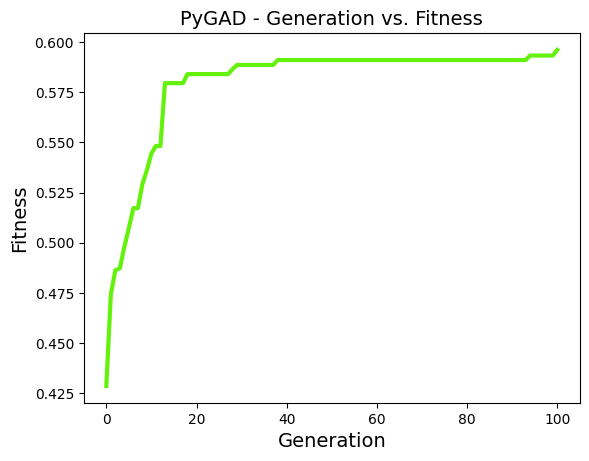

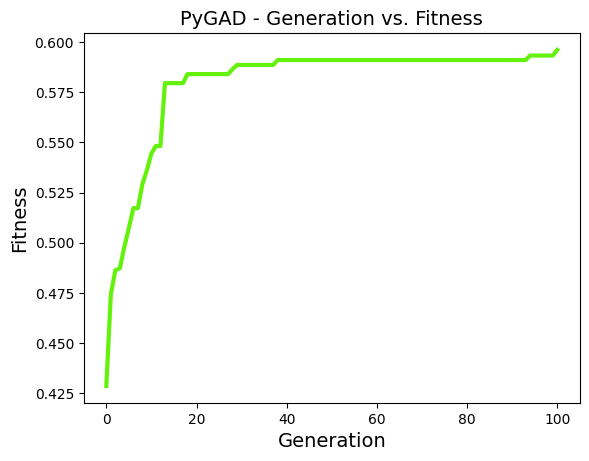

In [9]:
# Plot fitness over generations
ga_instance.plot_fitness()

In [10]:
# Extract selected sensor IDs
selected_indices = final_solution[(final_solution != 0) & (final_solution != -1)]
selected_ids = [possible_sensors_ids[i] for i in selected_indices]
selected_ids = np.array(selected_ids)

# Filter rows where first column matches selected_ids
matched_rows = np.array([row for row in filtered_coord if row[0] in selected_ids])

print(f"Selected {len(selected_ids)} sensor locations")
print(f"Selected IDs: {selected_ids}")

Selected 161 sensor locations
Selected IDs: ['91' '91' '92' '91' '556' '92' '91' '91' '91' '92' '478' '22' '21' '91'
 '6' '67' '1' '92' '811' '91' '1' '21' '535' '1' '92' '91' '22' '91' '21'
 '92' '1' '92' '134' '1' '1' '414' '91' '92' '92' '92' '91' '91' '91' '91'
 '91' '22' '1' '21' '311' '305' '22' '320' '92' '1' '91' '811' '653' '1'
 '864' '92' '92' '92' '92' '6' '22' '7' '713' '21' '22' '85' '21' '720'
 '21' '92' '1' '1' '1' '22' '4' '405' '235' '91' '265' '187' '232' '91'
 '281' '92' '71' '22' '92' '92' '91' '22' '22' '22' '22' '801' '91' '91'
 '22' '92' '22' '7' '92' '91' '285' '556' '21' '91' '712' '92' '478' '92'
 '85' '21' '638' '1' '16' '21' '634' '91' '476' '22' '22' '92' '21' '92'
 '22' '85' '21' '92' '21' '91' '91' '91' '21' '312' '22' '92' '21' '92'
 '91' '320' '21' '92' '91' '92' '305' '92' '22' '21' '21' '91' '21' '92'
 '7' '398' '4' '92' '21']


## Step 4: Visualize Selected Sensor Locations

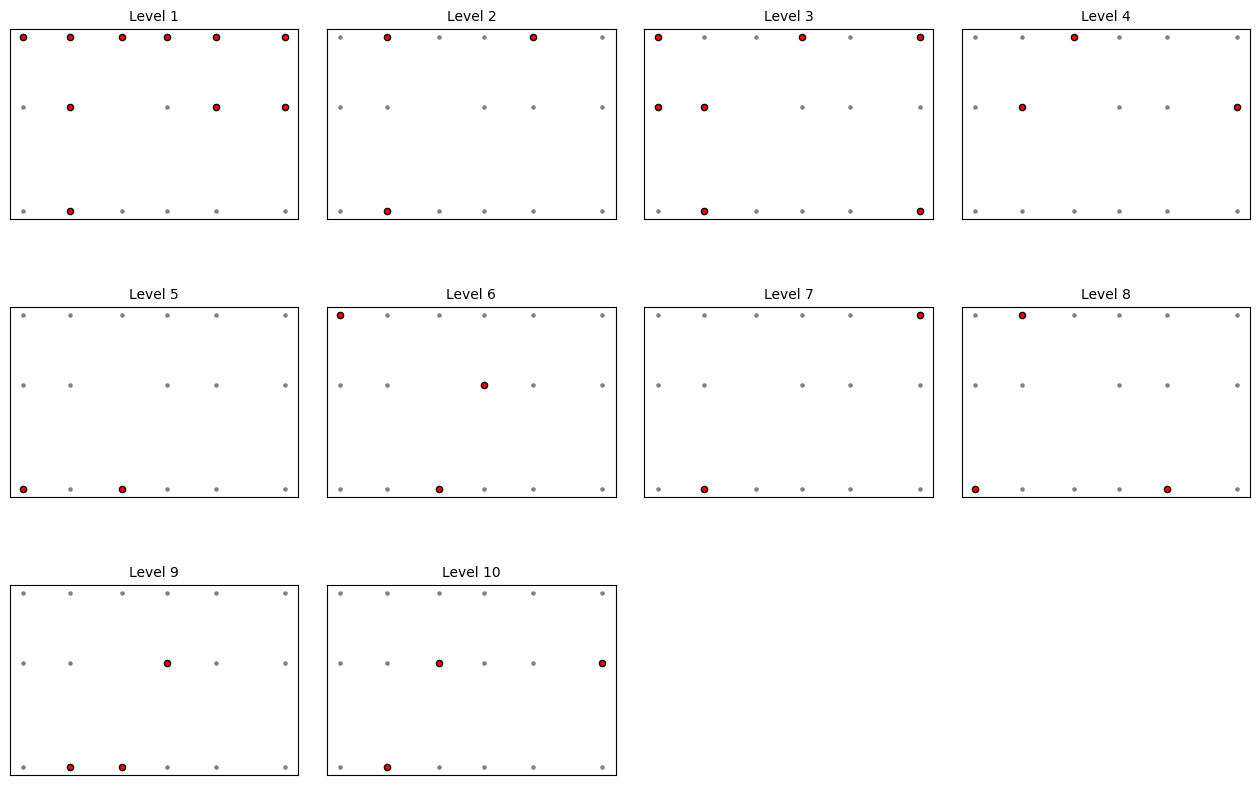

In [11]:
from src.visualization import plot_scatter_by_z_levels

# Plot all candidate sensors with selected ones highlighted
plot_scatter_by_z_levels(filtered_coord, matched_rows[:, 0])

In [12]:
# Sub-select: max 5 sensors per Z-level for practical placement
from collections import defaultdict

groups = defaultdict(list)
for row in matched_rows:
    z = row[-1]
    groups[z].append(row)

final_selected_ids = []
for z, rows in groups.items():
    selected = rows[:5]
    final_selected_ids.extend(row[0] for row in selected)

final_selected_ids = np.array(final_selected_ids)
print(f"Final sensor selection (max 5 per Z-level): {len(final_selected_ids)} sensors")
print(f"IDs: {final_selected_ids}")

Final sensor selection (max 5 per Z-level): 32 sensors
IDs: ['801' '864' '811' '712' '713' '720' '634' '638' '653' '556' '535' '398'
 '405' '414' '476' '478' '232' '235' '187' '305' '285' '311' '312' '320'
 '67' '85' '71' '16' '4' '6' '7' '21']
